In [1]:
import SALib
from SALib.sample import saltelli
from SALib.analyze import sobol
from SALib.test_functions import Ishigami
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
problem = {
    'num_vars': 10,
    'names': ['c_a', 'c_d', 'c_m', 'dmax', 'dmin', 
              'mmax', 'mmin', 'eta1', 'eta2', 'eta3'],
    'bounds': [ [0.5*0.4,    2.0*0.4],
                [0.5*0.1,    2.0*0.1],
                [0.5*0.5,    2.0*0.5],
                [0.5*2,      2.0*2],
                [0.5*0.0005, 2.0*0.0005],
                [0.5*0.12,   2.0*0.12],
                [0.5*0.06,   2.0*0.06],
                [0.5*5,      2.0*5],
                [0.5*5,      2.0*5],
                [0.5*15,     2.0*15]]
}

param_values = saltelli.sample(problem, calc_second_order=False, N=512)
param_values.shape

/tmp/ipykernel_1971109/2927388769.py:17: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5.1 Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, calc_second_order=False, N=512)


(6144, 10)

In [3]:
N_values = []
for sample_id in range(6144):
    mat = np.load(f"../data/sobol/sample_{sample_id}/iter_0.npz")
    
    N_tmp = mat["Nr"]
    N_tmp = np.hstack([N_tmp,mat["Ny"]])
    N_tmp = np.hstack([N_tmp,mat["Ng"]])
    N_tmp = np.hstack([N_tmp,mat["Nd"][1:]])    
    
    N_values.append(N_tmp)
N_values = np.array(N_values)

In [4]:
sobol_indices = [sobol.analyze(problem, Y, calc_second_order=False) for Y in N_values.T]

S1s = np.array([s['ST'] for s in sobol_indices])

S1_mean = np.mean(S1s,axis=0)

/home/hpc/nardinij/miniconda3/envs/FUCCI_ABM2D/lib/python3.12/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


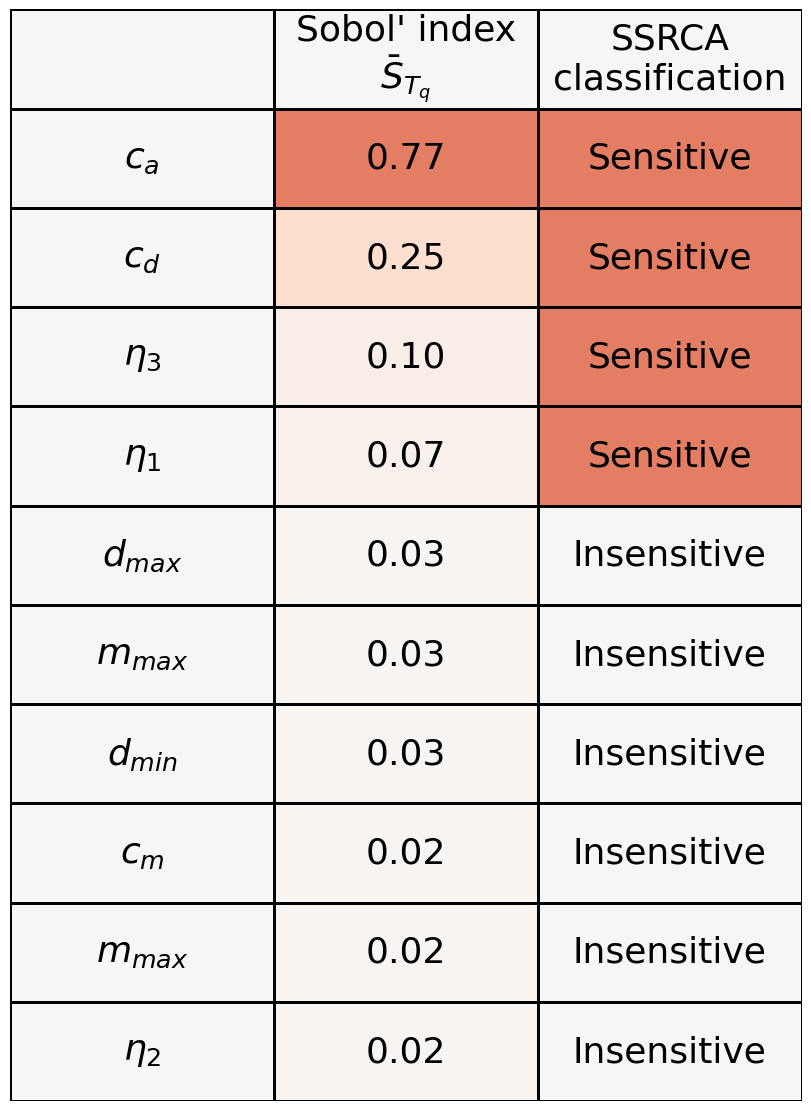

In [7]:
ST_values = S1_mean
param_strings = ["$c_a$", 
                 "$c_d$", 
                 "$c_m$", 
                 "$d_{max}$", 
                 "$d_{min}$", 
                 "$m_{max}$", 
                 "$m_{max}$", 
                 r"$\eta_1$", 
                 r"$\eta_2$", 
                 r"$\eta_3$"]

ST_labels = np.array([ f"{p} \n $S_T$ = {round(val,2)}" for (p,val) in zip(param_strings,ST_values)])

sort_indices = np.argsort(ST_values)[::-1]
ST_values = ST_values[sort_indices]
param_strings = [param_strings[i] for i in sort_indices]

SSRCA_ind = 0.77*np.array([1,1,0,0,0,0,0,1,0,1])[:,None]
SSRCA_ind = SSRCA_ind[sort_indices]

plt.figure(figsize=(8, 11),layout="constrained")

heatmap_vals = np.hstack([np.zeros((10,1)),ST_values[:,None],SSRCA_ind])

#pad with zeros for titles
heatmap_vals = np.vstack([np.zeros((1,3)),heatmap_vals])
ax = sns.heatmap(heatmap_vals, annot=False, cmap="RdBu_r", 
                 center=0, linewidths=1, cbar=False,vmax = 1.5,
                 linecolor="k")#,

# Manually add custom labels (string + value)
for i in range(10):
    
    #param names
    ax.text(0.5, i + 1.5, f"{param_strings[i]}",
            ha='center', va='center', color='black', fontsize=26)

    #Sobol ind
    ax.text(1.5, i + 1.5, f"{round(ST_values[i],2):.2f}", 
            ha='center', va='center', color='black', fontsize=26)

    if SSRCA_ind[i] == 0.77:
        sens_string = "Sensitive"
    else:
        sens_string = "Insensitive"
        
    ax.text(2.5, i + 1.5, f"{sens_string}", 
            ha='center', va='center', color='black', fontsize=26)

ax.text(1.5, 0.5, "Sobol' index\n" + r"$\bar{S}_{T_q}$", 
        ha='center', va='center', color='black', fontsize=26)
ax.text(2.5, 0.5, "SSRCA\nclassification", 
        ha='center', va='center', color='black', fontsize=26)

    
# Show the plot
plt.xticks([])
plt.yticks([])

plt.savefig("../figures/Sobol_SSRCA_heatmap_cell_counts.pdf")

In [8]:
%load_ext watermark

%watermark -n -u -v -iv -w

Last updated: Fri May 23 2025

Python implementation: CPython
Python version       : 3.12.4
IPython version      : 8.25.0

seaborn   : 0.13.2
SALib     : 1.5.1
matplotlib: 3.8.4
numpy     : 1.26.4

Watermark: 2.5.0

